In [54]:
from pathlib import Path
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [37]:
PROCESSED_DIR = Path("../data/processed")

# Load datasets
train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
val   = pd.read_parquet(PROCESSED_DIR / "val.parquet")
test  = pd.read_parquet(PROCESSED_DIR / "test.parquet")

# Load feature names
feature_cols = pd.read_csv(PROCESSED_DIR / "feature_cols.csv")["feature"].tolist()

target_col = "SepsisLabel"

# Create X and y
X_train = train[feature_cols]
y_train = train[target_col]

X_val = val[feature_cols]
y_val = val[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1086436, 78)
y_train shape: (1086436,)


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

Scale Features

In [39]:
# Initialize scaler
scaler = StandardScaler()

# Fit on train only
X_train_scaled = scaler.fit_transform(X_train)

# Apply to val and test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


Logistic Regression

In [41]:
# Initialize Logistic Regression
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

# Train
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression training completed.")

c:\Users\Nikhitha\OneDrive\Documents\EarlySepsisPrediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression training completed.


In [42]:
# Predict probabilities
val_probs = log_reg.predict_proba(X_val_scaled)[:, 1]

# Compute metrics
val_auroc = roc_auc_score(y_val, val_probs)
val_auprc = average_precision_score(y_val, val_probs)

print("Validation AUROC:", round(val_auroc, 4))
print("Validation AUPRC:", round(val_auprc, 4))

Validation AUROC: 0.7702
Validation AUPRC: 0.0573


XGBoost

In [43]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

Compute class imbalance weight

In [44]:
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
scale_pos_weight = neg / pos

print("Train positives:", pos)
print("Train negatives:", neg)
print("scale_pos_weight:", round(scale_pos_weight, 2))

Train positives: 19560
Train negatives: 1066876
scale_pos_weight: 54.54


Create DMatrix

In [45]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)
dtest  = xgb.DMatrix(X_test, label=y_test)

Training XGBoost with early stopping

In [46]:
params = {
    "objective": "binary:logistic",
    "eval_metric": ["auc", "aucpr"],   # AUROC + AUPRC during training
    "tree_method": "hist",             # faster on large datasets
    "max_depth": 6,
    "eta": 0.05,                       # learning rate
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 1,
    "reg_lambda": 1.0,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42
}

evals = [(dtrain, "train"), (dval, "val")]

xgb_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50
)

print("Best iteration:", xgb_model.best_iteration)

[0]	train-auc:0.74576	train-aucpr:0.06142	val-auc:0.73742	val-aucpr:0.05303
[50]	train-auc:0.82389	train-aucpr:0.13674	val-auc:0.78975	val-aucpr:0.06787
[100]	train-auc:0.85027	train-aucpr:0.18089	val-auc:0.79588	val-aucpr:0.07048
[150]	train-auc:0.86747	train-aucpr:0.21532	val-auc:0.79558	val-aucpr:0.06971
Best iteration: 100


Evaluate on validation set (AUROC + AUPRC)

In [47]:
val_probs_xgb = xgb_model.predict(dval)

val_auroc_xgb = roc_auc_score(y_val, val_probs_xgb)
val_auprc_xgb = average_precision_score(y_val, val_probs_xgb)

print("XGBoost Validation AUROC:", round(val_auroc_xgb, 4))
print("XGBoost Validation AUPRC:", round(val_auprc_xgb, 4))

XGBoost Validation AUROC: 0.7956
XGBoost Validation AUPRC: 0.0698


Evaluate on validation set (AUROC + AUPRC)

In [48]:
print("Model comparison (Validation)")
print("----------------------------")
print("Logistic Regression  AUROC: 0.7743   AUPRC: 0.0597")
print(f"XGBoost             AUROC: {val_auroc_xgb:.4f}   AUPRC: {val_auprc_xgb:.4f}")

Model comparison (Validation)
----------------------------
Logistic Regression  AUROC: 0.7743   AUPRC: 0.0597
XGBoost             AUROC: 0.7956   AUPRC: 0.0698


In [49]:
# --- XGBoost: Test set evaluation  ---

test_probs_xgb = xgb_model.predict(dtest)

test_auroc_xgb = roc_auc_score(y_test, test_probs_xgb)
test_auprc_xgb = average_precision_score(y_test, test_probs_xgb)

print("XGBoost TEST AUROC:", round(test_auroc_xgb, 4))
print("XGBoost TEST AUPRC:", round(test_auprc_xgb, 4))

XGBoost TEST AUROC: 0.7935
XGBoost TEST AUPRC: 0.0756


In [50]:
# --- Logistic Regression: Test set evaluation ---
test_probs_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

test_auroc_lr = roc_auc_score(y_test, test_probs_lr)
test_auprc_lr = average_precision_score(y_test, test_probs_lr)

print("LogReg TEST AUROC:", round(test_auroc_lr, 4))
print("LogReg TEST AUPRC:", round(test_auprc_lr, 4))

LogReg TEST AUROC: 0.7685
LogReg TEST AUPRC: 0.0601


In [51]:
results = pd.DataFrame([
    {"model": "Logistic Regression", "split": "val",  "auroc": 0.7743, "auprc": 0.0597},
    {"model": "XGBoost",            "split": "val",  "auroc": 0.8013, "auprc": 0.0700},
    {"model": "Logistic Regression", "split": "test", "auroc": test_auroc_lr, "auprc": test_auprc_lr},
    {"model": "XGBoost",            "split": "test", "auroc": test_auroc_xgb, "auprc": test_auprc_xgb},
])

results

,model,split,auroc,auprc
0,Logistic Regression,val,0.774300,0.059700
1,XGBoost,val,0.801300,0.070000
2,Logistic Regression,test,0.768502,0.060053
3,XGBoost,test,0.793498,0.075636


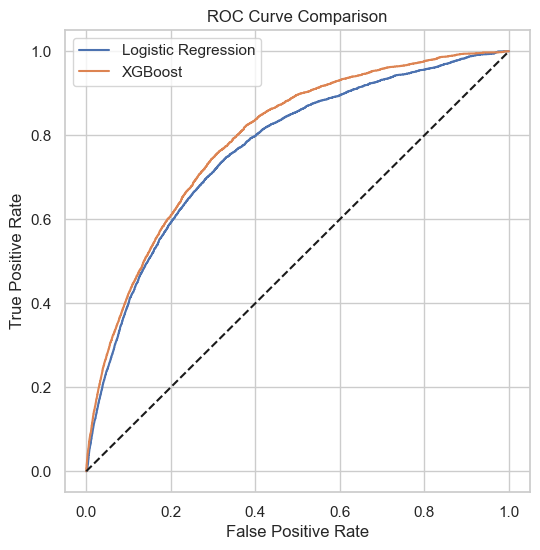

In [55]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, test_probs_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, test_probs_xgb)

plt.figure(figsize=(6,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

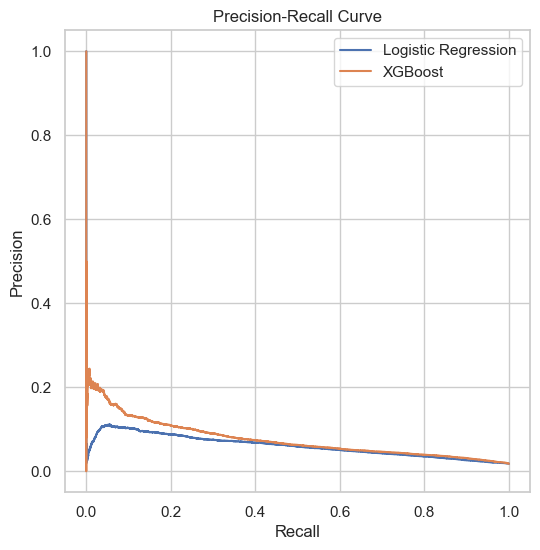

In [56]:
from sklearn.metrics import precision_recall_curve

prec_lr, rec_lr, _ = precision_recall_curve(y_test, test_probs_lr)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, test_probs_xgb)

plt.figure(figsize=(6,6))

plt.plot(rec_lr, prec_lr, label="Logistic Regression")
plt.plot(rec_xgb, prec_xgb, label="XGBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

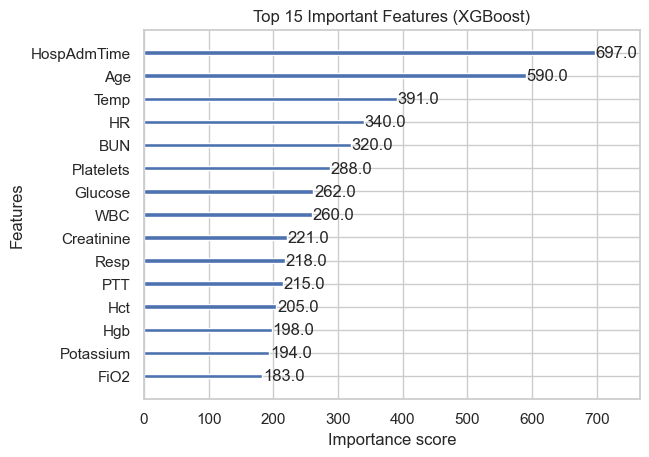

In [57]:
xgb.plot_importance(xgb_model, max_num_features=15)
plt.title("Top 15 Important Features (XGBoost)")
plt.show()

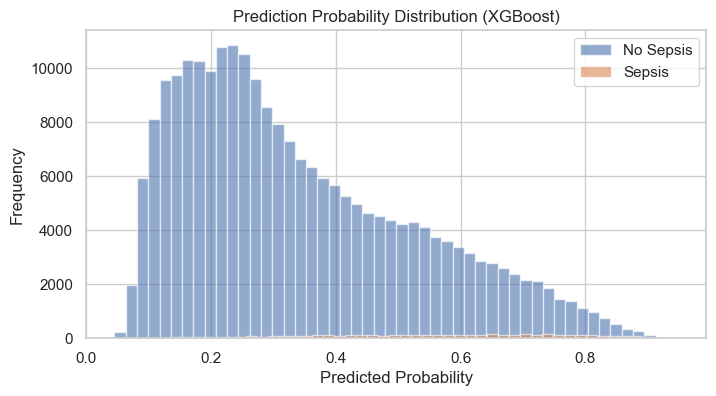

In [58]:
plt.figure(figsize=(8,4))

plt.hist(test_probs_xgb[y_test==0], bins=50, alpha=0.6, label="No Sepsis")
plt.hist(test_probs_xgb[y_test==1], bins=50, alpha=0.6, label="Sepsis")

plt.title("Prediction Probability Distribution (XGBoost)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

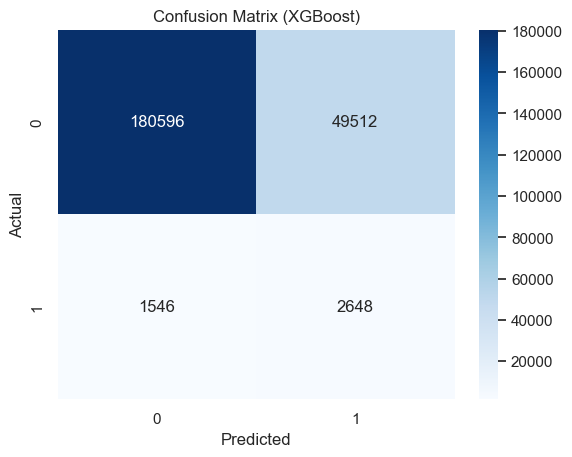

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

threshold = 0.5
pred_labels = (test_probs_xgb > threshold).astype(int)

cm = confusion_matrix(y_test, pred_labels)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()